# Position Assigner — Model Training

Trains a classifier to label each telemetry row with one of 11 fine-grained
flight attitude classes:

| Label | Meaning |
|---|---|
| `taxing` | On the ground, taxiing |
| `landing-takeoff` | Takeoff or landing roll |
| `ascending_straight` | Climbing, wings level |
| `ascending_left` | Climbing, left bank |
| `ascending_right` | Climbing, right bank |
| `stable_straight` | Level flight, wings level |
| `stable_left` | Level flight, left bank |
| `stable_right` | Level flight, right bank |
| `descending_straight` | Descending, wings level |
| `descending_left` | Descending, left bank |
| `descending_right` | Descending, right bank |

**Features used:** `acc_x`, `pitch`, `roll`, `turn_rate`, `magnetic_heading`, `ground_speed`, `vertical_speed`

**Config:** Place a `config.yml` inside the `notebooks/` folder with the shape:
```yaml
database:
  username: your-db-user
  password: your-db-password
  ip_address: your-db-host
  port: '50000'
  db_name: YOUR_DB_NAME
```

In [3]:
import sys
sys.path.insert(0, '..')  # so we can import from the project root

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from db_connection_params_handler import ConnectionParamsHandler
from db_factory import make_db_manager
from db_handlers.ibm_db2.airplane_info_db_access import AirplaneInfoDBAccess
from db_handlers.ibm_db2.MQTT_db_access import TelemetryMQTTDatabaseAccess
from mappers.telemetry_mapper import FormattedTelemetryMapper
from logic.position_assigner_instance import position_assigner


/opt/anaconda3/envs/intuosdash/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/intuosdash/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/intuosdash/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from ve

## 1. Connect to the database

In [ ]:
CONFIG_PATH = '/Users/adebanjiadelowo/Documents/GitHub/intuos-fdm-dashboard/config_notebook.yml'

connection = ConnectionParamsHandler(connection_filename=CONFIG_PATH)
db_manager = make_db_manager(connection)
telemetry_access = TelemetryMQTTDatabaseAccess(manager=db_manager)
print('Connected.')

Connected.


In [12]:
print(connection.db_name)
print(connection.ip_address, connection.port)

DB_SUN01
REDACTED_DB2_HOST 27010


In [13]:
airplane_access = AirplaneInfoDBAccess(db_manager)
airplane_info = airplane_access.get_all_airplane_info()

In [14]:
airplane_info

,marche,country,tc_holder,typedesignator,icao_id,numserie,annocostr,annoimma,ulmsn,experimentalsn,...,solo_01,use_camo_01,manual_input_01,glidersn,towingsn,engine_desc,hp,vfrn_01,ifu_present_01,fr_enable_01
0,D-0206,DE,193,K7,0,AB/7281,1961,2022,N,N,...,1,0,1,S,S,,,0,0,0
1,D-ENDK,DE,AVI346,DR40,37814,1318,1978,2021,N,N,...,1,0,1,N,N,,,0,1,1
2,D-KCIK,DE,SPO394,RF5,38772,51003,1971,2015,N,N,...,1,0,1,S,N,,,0,0,0
3,I-AMAT,IT,6,C152,31641,152-80995,1978,1986,N,N,...,0,0,0,N,N,None,None,0,0,0
4,I-CCBI,IT,4,M7,36013,10075C,1989,1989,N,N,...,1,0,1,N,N,,,0,1,0
5,I-CGTB,IT,34,201B,0,201B062,1988,2021,N,N,...,1,0,1,S,S,None,None,0,0,0
6,I-GDEL,IT,6001,P2006,0,,0,0,N,N,...,0,0,0,N,N,None,None,0,0,0
7,I-LZZY,IT,230,P28U,29880,28R-8031001,1981,2017,N,N,...,1,0,1,N,N,,,0,1,1
8,I-SRAA,IT,AVI346,DR40,37832,2789,2025,2025,N,N,...,1,0,1,N,N,DIESEL,0,1,0,0
9,I-SRAV,IT,6,C152,31641,152-84056,1979,2011,N,N,...,1,0,1,N,N,,,0,1,1


## 2. Pull telemetry with current attitude labels

We run the existing `PositionAssigner` pipeline to produce labelled rows,
then treat its `attitude` output as the ground truth for retraining.
You can also provide manually corrected labels by editing the DataFrame below.

In [20]:
QUERIES = [
    # (registration, start_date, end_date)
    ('I-SRAV', '2025-01-01', '2025-06-30'),
    ('I-CCBI', '2025-01-01', '2025-06-30'),
    ('D-ENDK', '2025-01-01', '2025-06-30')
    # add more as needed
]

frames = []
for marca, start, end in QUERIES:
    print(f'Fetching {marca}  {start} → {end} ...')
    raw = telemetry_access.get_telemetry_by_marca_datetime_interval(
        marca=marca, start_datetime=start, end_datetime=end
    )
    if raw.dropna(how='all').empty:
        print('  no data')
        continue
    mapper = FormattedTelemetryMapper(df_chunk_generator=raw, position_assigner=position_assigner)
    df = mapper.new_generate_telemetry_samples()
    frames.append(df)
    print(f'  {len(df):,} rows')

data = pd.concat(frames, ignore_index=True)
print(f'\nTotal rows: {len(data):,}')
data.head()

Fetching I-SRAV  2025-01-01 → 2025-06-30 ...
  278,571 rows
Fetching I-CCBI  2025-01-01 → 2025-06-30 ...
  no data
Fetching D-ENDK  2025-01-01 → 2025-06-30 ...
  no data

Total rows: 278,571


,magnetic_heading,acc_x,acc_y,acc_z,pitch,roll,turn_rate,latitude,longitude,altitude,...,heading,vertical_speed,elevation,registration_id,id,date_time,label,attitude,unix_timestamp,height
0,NaN,0.09,-0.18,0.92,-1.0,-0.0,-0.0,42.383472,13.309072,2234.0,...,177.8,-0.16,2234.0,I-SRAV,1736953413,2025-01-15 15:03:33.600,9,stable_straight,1736953413,0.0
1,NaN,0.19,0.09,1.25,-1.0,-0.0,-0.0,42.383228,13.309079,2232.0,...,178.9,-0.21,2218.0,I-SRAV,1736953415,2025-01-15 15:03:35.500,2,ascending_straight,1736953415,14.0
2,NaN,0.21,0.04,0.99,-3.0,-0.0,-0.0,42.382717,13.309091,2231.0,...,179.4,-0.33,2218.0,I-SRAV,1736953416,2025-01-15 15:03:36.500,9,stable_straight,1736953416,13.0
3,NaN,0.21,0.09,0.99,-4.0,0.0,-0.0,42.382175,13.309118,2231.0,...,178.0,-0.58,2218.0,I-SRAV,1736953418,2025-01-15 15:03:38.600,9,stable_straight,1736953418,13.0
4,NaN,0.19,0.05,1.12,-5.0,-0.0,0.0,42.381886,13.309134,2231.0,...,178.6,-0.58,2218.0,I-SRAV,1736953419,2025-01-15 15:03:39.500,9,stable_straight,1736953419,13.0


In [21]:
data.to_csv('telemetry_data.csv', index=False)

In [ ]:
df = pd.read_csv('telemetry_data.csv')

In [ ]:
df.shape

(278571, 21)

In [ ]:
df.columns

Index(['magnetic_heading', 'acc_x', 'acc_y', 'acc_z', 'pitch', 'roll',
       'turn_rate', 'latitude', 'longitude', 'altitude', 'ground_speed',
       'heading', 'vertical_speed', 'elevation', 'registration_id', 'id',
       'date_time', 'label', 'attitude', 'unix_timestamp', 'height'],
      dtype='object')

In [ ]:
FEATURES = ['acc_x', 'pitch', 'roll', 'turn_rate', 'magnetic_heading', 'ground_speed', 'vertical_speed']
data = df[FEATURES]

In [66]:
len(FEATURES)

7

In [ ]:
df.shape

(278571, 7)

In [68]:
df["attitude"]

0            stable_straight
1         ascending_straight
2            stable_straight
3            stable_straight
4            stable_straight
                 ...        
278566                taxing
278567                taxing
278568                taxing
278569                taxing
278570                taxing
Name: attitude, Length: 278571, dtype: object

In [41]:
data["pitch"]

0        -1.0
1        -1.0
2        -3.0
3        -4.0
4        -5.0
         ... 
278566   -1.0
278567   -2.0
278568   -3.0
278569   -5.0
278570   -6.0
Name: pitch, Length: 278571, dtype: float64

In [42]:
data['roll']

0        -0.0
1        -0.0
2        -0.0
3         0.0
4        -0.0
         ... 
278566   -3.0
278567   -4.0
278568   -5.0
278569   -5.0
278570   -5.0
Name: roll, Length: 278571, dtype: float64

## 3. Prepare features and labels

In [70]:
# FEATURES = ['acc_x', 'pitch', 'roll', 'turn_rate', 'magnetic_heading', 'ground_speed', 'vertical_speed']

# # Same clipping as FlightSeparator (catch sensor outliers)
# data['pitch']          = data['pitch'].clip(-180, 180)
# data['roll']           = data['roll'].clip(-180, 180)
# data['ground_speed']   = data['ground_speed'].clip(-1, 500)
# data['vertical_speed'] = data['vertical_speed'].clip(-5000, 5000)

# # Drop rows where any feature or label is missing
# data = data.dropna(subset=FEATURES + ['attitude'])

print(df['attitude'].value_counts())
# data[FEATURES + ['attitude']].head()

attitude
ascending_straight     97110
stable_straight        92545
descending_straight    20637
ascending_left         20508
stable_left            13903
ascending_right        10998
stable_right            8278
descending_left         6091
landing-takeoff         3571
descending_right        2549
taxing                  2381
Name: count, dtype: int64


## 4. Train / test split

In [71]:
X = df[FEATURES].values
y = df['attitude'].values

In [73]:
X = df[FEATURES]  # keep as DataFrame

In [74]:
cat_cols = X.select_dtypes(include='object').columns
X[cat_cols] = X[cat_cols].astype('category')

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,}   Test: {len(X_test):,}')

Train: 222,856   Test: 55,715


In [60]:
# cat_cols = X_train.select_dtypes(include='object').columns
# X_train[cat_cols] = X_train[cat_cols].astype('category')
# X_test[cat_cols] = X_test[cat_cols].astype('category')

## 5. Train model

LightGBM — faster training than Random Forest, generally higher accuracy
on tabular sensor data, and better at capturing feature interactions.
Drop-in sklearn-compatible replacement: all downstream cells are unchanged.


In [76]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)
model.fit(X_train, y_train)
print('Training complete.')


Training complete.


## 6. Evaluate

In [77]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1_weighted', n_jobs=-1)
print(f'5-fold CV F1 (weighted): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

                     precision    recall  f1-score   support

     ascending_left       0.93      0.93      0.93      4102
    ascending_right       0.91      0.90      0.90      2200
 ascending_straight       0.95      0.95      0.95     19422
    descending_left       0.86      0.85      0.85      1218
   descending_right       0.85      0.83      0.84       510
descending_straight       0.89      0.87      0.88      4127
    landing-takeoff       0.95      0.91      0.93       714
        stable_left       0.88      0.87      0.87      2781
       stable_right       0.87      0.89      0.88      1656
    stable_straight       0.94      0.94      0.94     18509
             taxing       0.95      0.97      0.96       476

           accuracy                           0.93     55715
          macro avg       0.91      0.90      0.90     55715
       weighted avg       0.93      0.93      0.93     55715

5-fold CV F1 (weighted): 0.918 ± 0.021


In [78]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42)
pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False).head(10)


Exception ignored in: <function ResourceTracker.__del__ at 0x106628fe0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/intuosdash/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/intuosdash/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/intuosdash/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10702cfe0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/intuosdash/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/intuosdash/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/intuosdash/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exceptio

turn_rate           0.286878
vertical_speed      0.212905
pitch               0.171135
acc_x               0.159806
ground_speed        0.159307
roll                0.106273
magnetic_heading    0.000000
dtype: float64

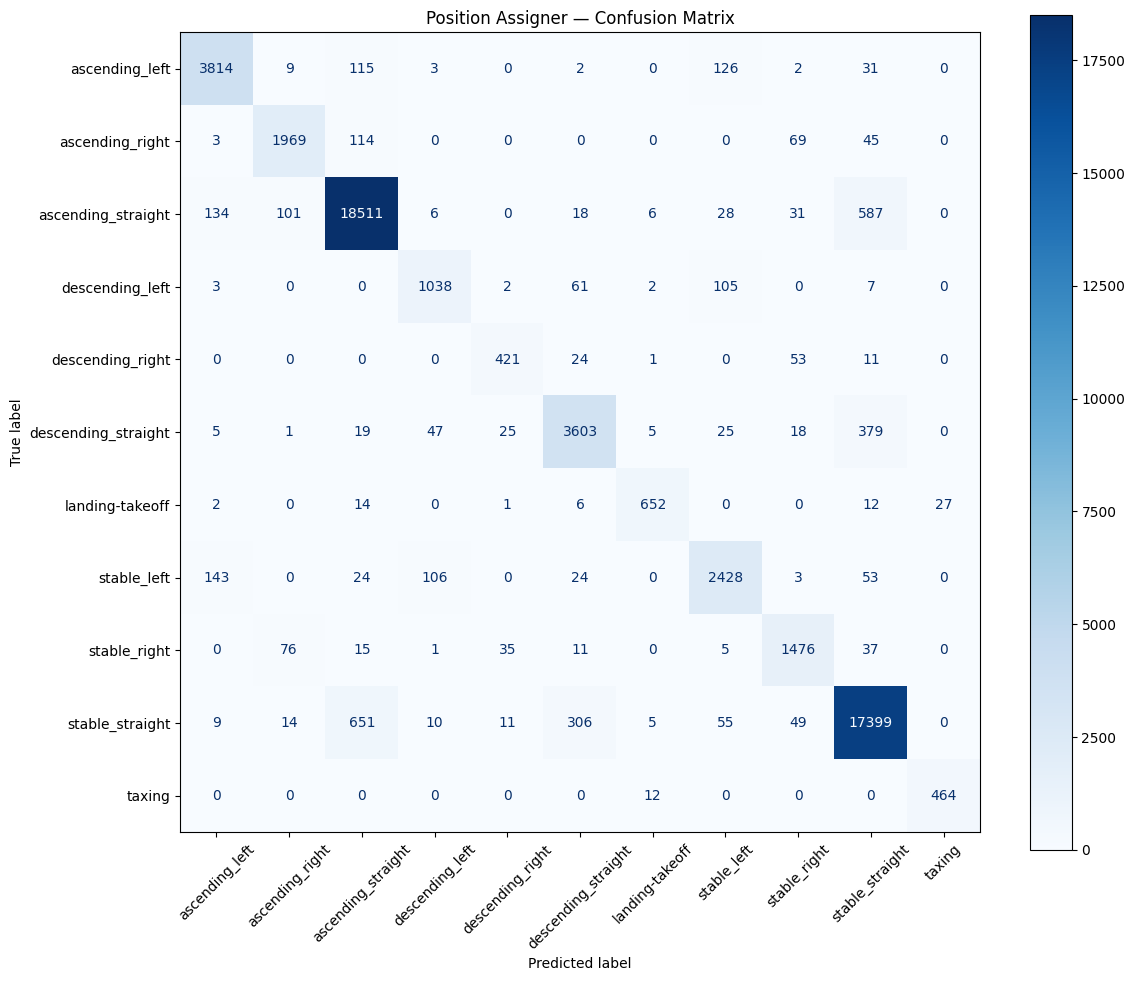

In [79]:
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Position Assigner — Confusion Matrix')
plt.tight_layout()
plt.show()

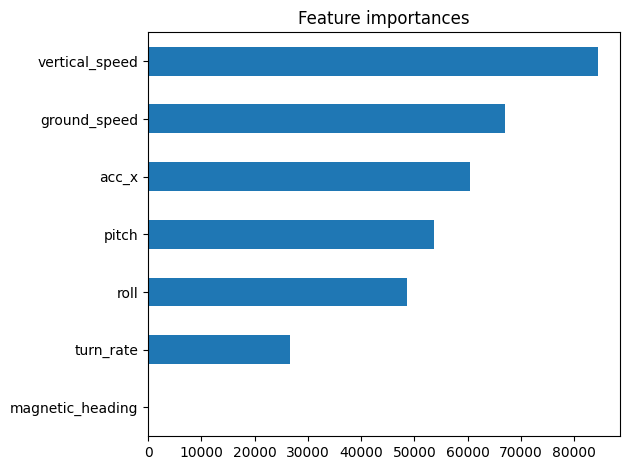

In [80]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
importances.plot.barh()
plt.title('Feature importances')
plt.tight_layout()
plt.show()

## 7. Save artefacts

Drop the output files into `logic/position_assignment_data/` to replace `f1.pkl`.

> **Note on label format:** `PositionAssigner` loads `label_names` as a
> `{class_name: integer_index}` dict (inverse of the model's class ordering).
> The cell below builds that mapping automatically from `model.classes_`.

In [81]:
OUT_DIR = Path('../logic/position_assignment_data')
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'retrained'  # change to 'f1' to replace the existing model in-place

# Model
joblib.dump(model, OUT_DIR / f'{MODEL_NAME}.pkl')

# Class names — {class_name: index} as expected by PositionAssigner
class_names = {name: idx for idx, name in enumerate(model.classes_)}
with open(OUT_DIR / f'{MODEL_NAME}_class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)

# Feature list
with open(OUT_DIR / f'{MODEL_NAME}_selected_features.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)

print('Saved:')
for p in OUT_DIR.glob(f'{MODEL_NAME}*'):
    print(' ', p)

print('\nTo use the new model, update logic/position_assigner_instance.py:')
print(f"  model_file_path='logic/position_assignment_data/{MODEL_NAME}.pkl'")
print(f"  label_names_file_path='logic/position_assignment_data/{MODEL_NAME}_class_names.json'")
print(f"  features_file_path='logic/position_assignment_data/{MODEL_NAME}_selected_features.json'")

Saved:
  ../logic/position_assignment_data/retrained_class_names.json
  ../logic/position_assignment_data/retrained_selected_features.json
  ../logic/position_assignment_data/retrained.pkl

To use the new model, update logic/position_assigner_instance.py:
  model_file_path='logic/position_assignment_data/retrained.pkl'
  label_names_file_path='logic/position_assignment_data/retrained_class_names.json'
  features_file_path='logic/position_assignment_data/retrained_selected_features.json'
